# EDA

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [2]:
customers=pd.read_csv('customers_clean.csv',parse_dates=["Signup_Date"])
plans=pd.read_csv('plans_clean.csv')
subscriptions=pd.read_csv('subscriptions_clean.csv',parse_dates=["Start_Date","End_Date"])
payments=pd.read_csv('payments_clean.csv',parse_dates=['Payment_Date'])
support=pd.read_csv('support_clean.csv')
usage=pd.read_csv('usage_clean.csv',parse_dates=['Event_Date'])

In [3]:
customers

,Customer_Id,Signup_Date,Country,Industry,Company_Size,Segment
0,CUST_2000,2025-09-15,Unknown,Logistics,unknown,SMB
1,CUST_2001,2025-10-10,Unknown,E-commerce,500+,ENT
2,CUST_2002,2025-03-19,Unknown,Logistics,201-500,SMB
3,CUST_2003,2025-11-30,USA,Finance,51-200,SMB
4,CUST_2004,2025-01-30,Unknown,Unknown,51-200,SMB
...,...,...,...,...,...,...
1495,CUST_3495,2025-09-30,USA,SaaS,500+,MID
1496,CUST_3496,2025-07-19,USA,Healthcare,11-50,ENT
1497,CUST_3497,2025-03-25,Canada,SaaS,11-50,SMB
1498,CUST_3498,2025-01-13,UK,Unknown,51-200,ENT


In [4]:
plans

,Plan_Id,Plan_Name,Monthly_Price,Billing_Cycle
0,p_basic,Basic,29.0,Monthly
1,p_pro,Pro,79.0,Monthly
2,p_ent,Enterprise,499.0,Annual


In [5]:
subscriptions

,Subscription_Id,Customer_Id,Plan_Id,Start_Date,End_Date,Status,Subscription_Days
0,SUB_30000,CUST_2000,p_ent,2025-09-16,NaT,Active,0
1,SUB_30001,CUST_2001,p_pro,2025-10-10,NaT,Active,0
2,SUB_30002,CUST_2002,p_ent,2025-03-21,NaT,Active,0
3,SUB_30004,CUST_2004,p_ent,2025-01-30,NaT,Active,0
4,SUB_30005,CUST_2005,p_pro,2025-04-28,NaT,Active,0
...,...,...,...,...,...,...,...
1353,SUB_31494,CUST_3494,p_pro,2025-01-25,2025-07-05,Churned,161
1354,SUB_31495,CUST_3495,p_pro,2025-09-30,NaT,Active,0
1355,SUB_31496,CUST_3496,p_ent,2025-07-20,NaT,Active,0
1356,SUB_31497,CUST_3497,p_basic,2025-03-26,2025-11-11,Cancelled,230


In [6]:
payments

,Payment_Id,Subscription_Id,Payment_Date,Amount,Payment_Status,Payment_Method
0,PAY_500001,SUB_30000,2025-09-16,-499.0,Refunded,CREDIT_CARD
1,PAY_500002,SUB_30001,2025-10-13,79.0,Paid,STRIPE
2,PAY_500003,SUB_30002,2025-03-24,499.0,Failed,ACH
3,PAY_500004,SUB_30002,2025-04-23,499.0,Failed,PAYPAL
4,PAY_500005,SUB_30002,2025-05-21,499.0,Failed,CREDIT_CARD
...,...,...,...,...,...,...
2808,PAY_503058,SUB_31496,2025-07-21,499.0,Paid,STRIPE
2809,PAY_503059,SUB_31496,2025-08-22,499.0,Failed,CREDIT_CARD
2810,PAY_503060,SUB_31496,2025-09-18,499.0,Paid,CREDIT_CARD
2811,PAY_503061,SUB_31497,2025-03-27,-29.0,Refunded,STRIPE


In [7]:
usage

,Usage_Id,Customer_Id,Event_Date,Feature_Name,Login_Count,Session_Minutes
0,USG_700001,CUST_2000,2025-09-08,Dashboard_View,8,114.76
1,USG_700002,CUST_2000,2025-05-11,Export_Csv,3,44.68
2,USG_700003,CUST_2000,2025-01-17,Export_Csv,3,76.59
3,USG_700004,CUST_2000,2025-03-10,Export_Csv,8,58.81
4,USG_700005,CUST_2000,2025-05-25,Export_Csv,3,35.41
...,...,...,...,...,...,...
22697,USG_724752,CUST_2999,2025-01-20,Team_Invite,1,70.09
22698,USG_724753,CUST_2999,2025-01-14,Export_Csv,5,73.85
22699,USG_724754,CUST_2999,2025-05-20,Team_Invite,5,31.07
22700,USG_724755,CUST_2999,2025-10-25,Export_Csv,8,25.97


In [8]:
support

,Ticket_Id,Customer_Id,Ticket_Date,Priority,Category,Resolution_Time,Status
0,TCK_900001,CUST_2006,2025-02-17,High,Login Issue,12,Closed
1,TCK_900002,CUST_2006,2025-07-17,Low,API Down,41,Resolved
2,TCK_900003,CUST_2007,2025-08-23,Low,Login Issue,21,Closed
3,TCK_900004,CUST_2008,2025-11-10,Medium,Login Issue,43,Resolved
4,TCK_900005,CUST_2008,2025-07-22,Medium,Feature Request,1,Resolved
...,...,...,...,...,...,...,...
711,TCK_900780,CUST_3491,2025-07-02,Medium,Feature Request,8,Resolved
712,TCK_900781,CUST_3491,2025-03-02,High,API Down,19,Open
713,TCK_900782,CUST_3496,2025-04-09,Medium,Feature Request,64,Resolved
714,TCK_900783,CUST_3496,2025-08-07,Low,Login Issue,60,Closed


# Customers EDA

In [9]:
customers.shape

(1500, 6)

In [10]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Customer_Id   1500 non-null   object        
 1   Signup_Date   1500 non-null   datetime64[ns]
 2   Country       1500 non-null   object        
 3   Industry      1500 non-null   object        
 4   Company_Size  1500 non-null   object        
 5   Segment       1500 non-null   object        
dtypes: datetime64[ns](1), object(5)
memory usage: 70.4+ KB


In [11]:
customers.describe(include='all')

,Customer_Id,Signup_Date,Country,Industry,Company_Size,Segment
count,1500,1500,1500,1500,1500,1500
unique,1500,NaN,4,6,6,3
top,CUST_3499,NaN,USA,SaaS,1-10,MID
freq,1,NaN,523,269,274,529
mean,NaN,2025-07-04 03:25:26.400000,NaN,NaN,NaN,NaN
min,NaN,2025-01-01 00:00:00,NaN,NaN,NaN,NaN
25%,NaN,2025-04-04 00:00:00,NaN,NaN,NaN,NaN
50%,NaN,2025-07-10 12:00:00,NaN,NaN,NaN,NaN
75%,NaN,2025-10-02 00:00:00,NaN,NaN,NaN,NaN
max,NaN,2025-12-31 00:00:00,NaN,NaN,NaN,NaN


In [12]:
customers.columns

Index(['Customer_Id', 'Signup_Date', 'Country', 'Industry', 'Company_Size',
       'Segment'],
      dtype='object')

In [13]:
customers['Customer_Id'].nunique()

1500

In [14]:
country=customers['Country'].value_counts()
country

Country
USA        523
Canada     340
Unknown    337
UK         300
Name: count, dtype: int64

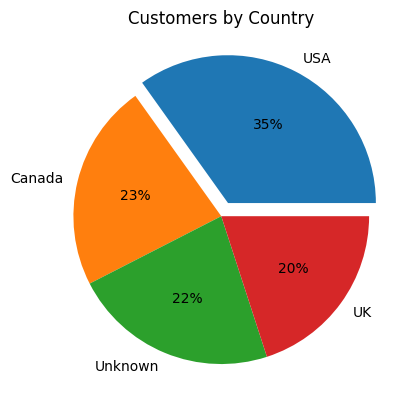

In [15]:
plt.pie(country,labels=country.index,autopct="%1.f%%",explode=(0.1,0,0,0))
plt.title("Customers by Country")
plt.show()

In [16]:
industry=customers['Industry'].value_counts().reset_index()
industry.columns=['Industry','Customers']
industry

,Industry,Customers
0,SaaS,269
1,Finance,263
2,E-commerce,260
3,Healthcare,254
4,Unknown,231
5,Logistics,223


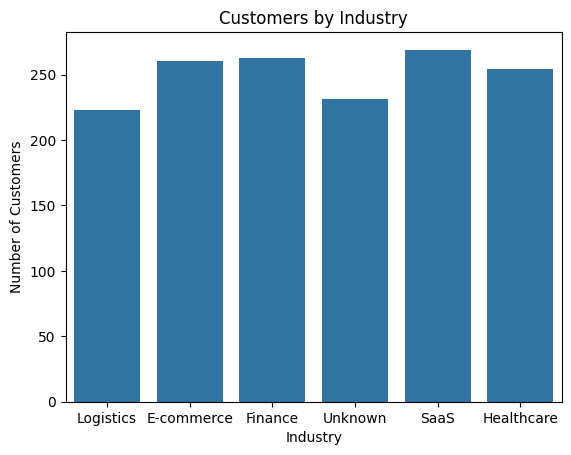

In [17]:
sns.countplot(data=customers,x='Industry')
plt.title("Customers by Industry")
plt.xlabel("Industry")
plt.ylabel("Number of Customers")
plt.show()

In [18]:
company=(customers["Company_Size"] .value_counts().reset_index())
company.columns =["Company_Size","Customers"]
company

,Company_Size,Customers
0,1-10,274
1,11-50,262
2,51-200,256
3,201-500,247
4,unknown,236
5,500+,225


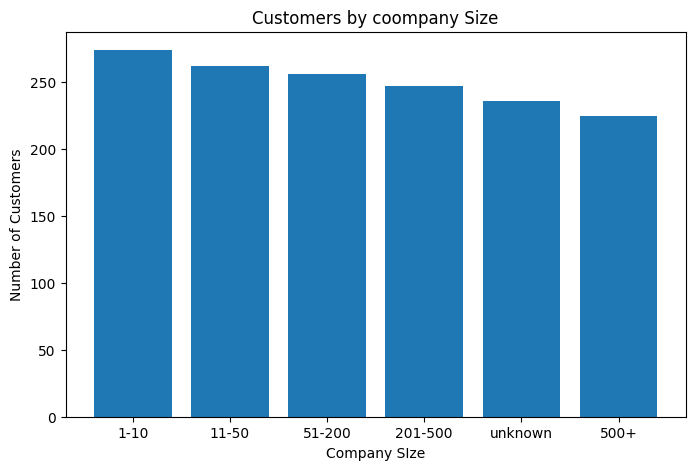

In [19]:
plt.figure(figsize=(8,5))
plt.bar(company["Company_Size"],company['Customers'])
plt.title('Customers by coompany Size')
plt.xlabel("Company SIze")
plt.ylabel("Number of Customers")
plt.show()

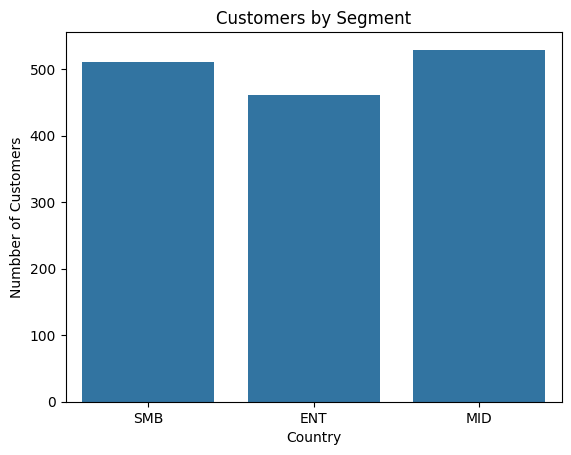

In [20]:
sns.countplot(data=customers,x='Segment')
plt.title("Customers by Segment")
plt.xlabel("Country")
plt.ylabel("Numbber of Customers")
plt.show()

In [21]:
monthly_signup = (customers.groupby(customers["Signup_Date"].dt.to_period("M")).size())
monthly_signup

Signup_Date
2025-01    125
2025-02    116
2025-03    120
2025-04    119
2025-05    114
2025-06    119
2025-07    120
2025-08    164
2025-09    123
2025-10    133
2025-11    121
2025-12    126
Freq: M, dtype: int64

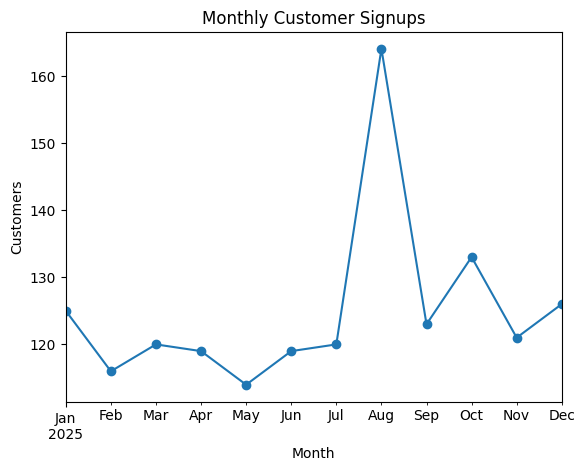

In [22]:
monthly_signup.plot(kind="line",marker="o")
plt.title("Monthly Customer Signups")
plt.xlabel("Month")
plt.ylabel("Customers")
plt.show()

# 2. Plans EDA

In [23]:
plans.shape

(3, 4)

In [24]:
plans.columns

Index(['Plan_Id', 'Plan_Name', 'Monthly_Price', 'Billing_Cycle'], dtype='object')

In [25]:
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Plan_Id        3 non-null      object 
 1   Plan_Name      3 non-null      object 
 2   Monthly_Price  3 non-null      float64
 3   Billing_Cycle  3 non-null      object 
dtypes: float64(1), object(3)
memory usage: 228.0+ bytes


In [26]:
plans.describe(include="all")

,Plan_Id,Plan_Name,Monthly_Price,Billing_Cycle
count,3,3,3.000000,3
unique,3,3,NaN,2
top,p_basic,Basic,NaN,Monthly
freq,1,1,NaN,2
mean,NaN,NaN,202.333333,NaN
std,NaN,NaN,258.134332,NaN
min,NaN,NaN,29.000000,NaN
25%,NaN,NaN,54.000000,NaN
50%,NaN,NaN,79.000000,NaN
75%,NaN,NaN,289.000000,NaN


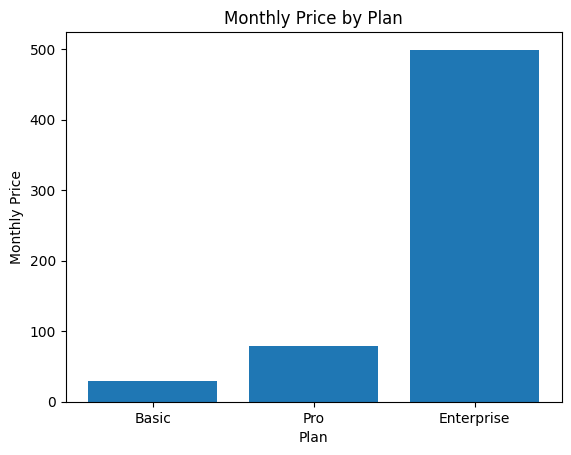

In [27]:
plt.bar(plans["Plan_Name"], plans["Monthly_Price"])
plt.title("Monthly Price by Plan")
plt.xlabel("Plan")
plt.ylabel("Monthly Price")
plt.show()

# 3. Subscriptions EDA

In [28]:
subscriptions

,Subscription_Id,Customer_Id,Plan_Id,Start_Date,End_Date,Status,Subscription_Days
0,SUB_30000,CUST_2000,p_ent,2025-09-16,NaT,Active,0
1,SUB_30001,CUST_2001,p_pro,2025-10-10,NaT,Active,0
2,SUB_30002,CUST_2002,p_ent,2025-03-21,NaT,Active,0
3,SUB_30004,CUST_2004,p_ent,2025-01-30,NaT,Active,0
4,SUB_30005,CUST_2005,p_pro,2025-04-28,NaT,Active,0
...,...,...,...,...,...,...,...
1353,SUB_31494,CUST_3494,p_pro,2025-01-25,2025-07-05,Churned,161
1354,SUB_31495,CUST_3495,p_pro,2025-09-30,NaT,Active,0
1355,SUB_31496,CUST_3496,p_ent,2025-07-20,NaT,Active,0
1356,SUB_31497,CUST_3497,p_basic,2025-03-26,2025-11-11,Cancelled,230


In [29]:
subscriptions.columns

Index(['Subscription_Id', 'Customer_Id', 'Plan_Id', 'Start_Date', 'End_Date',
       'Status', 'Subscription_Days'],
      dtype='object')

In [30]:
subscriptions.shape

(1358, 7)

In [31]:
subscriptions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1358 entries, 0 to 1357
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Subscription_Id    1358 non-null   object        
 1   Customer_Id        1358 non-null   object        
 2   Plan_Id            1358 non-null   object        
 3   Start_Date         1358 non-null   datetime64[ns]
 4   End_Date           393 non-null    datetime64[ns]
 5   Status             1358 non-null   object        
 6   Subscription_Days  1358 non-null   int64         
dtypes: datetime64[ns](2), int64(1), object(4)
memory usage: 74.4+ KB


In [32]:
subscriptions.describe(include='all')

,Subscription_Id,Customer_Id,Plan_Id,Start_Date,End_Date,Status,Subscription_Days
count,1358,1358,1358,1358,393,1358,1358.000000
unique,1358,1358,3,NaN,NaN,3,NaN
top,SUB_31499,CUST_3499,p_pro,NaN,NaN,Active,NaN
freq,1,1,678,NaN,NaN,965,NaN
mean,NaN,NaN,NaN,2025-07-05 14:08:18.379970304,2025-11-10 07:19:41.679389440,NaN,38.453608
min,NaN,NaN,NaN,2025-01-01 00:00:00,2025-02-10 00:00:00,NaN,0.000000
25%,NaN,NaN,NaN,2025-04-04 06:00:00,2025-08-15 00:00:00,NaN,0.000000
50%,NaN,NaN,NaN,2025-07-12 00:00:00,2025-11-11 00:00:00,NaN,0.000000
75%,NaN,NaN,NaN,2025-10-05 00:00:00,2026-02-11 00:00:00,NaN,54.000000
max,NaN,NaN,NaN,2026-01-01 00:00:00,2026-07-30 00:00:00,NaN,240.000000


In [33]:
status=subscriptions['Status'].value_counts()
status

Status
Active       965
Cancelled    263
Churned      130
Name: count, dtype: int64

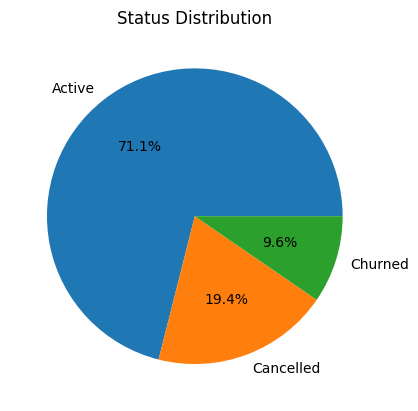

In [34]:
plt.pie(status,labels=status.index,autopct="%1.1f%%")
plt.title("Status Distribution")
plt.show()

In [35]:
monthly_subscriptions=(subscriptions.groupby(subscriptions['Start_Date'].dt.to_period('M')).size())
monthly_subscriptions

Start_Date
2025-01    113
2025-02    103
2025-03    108
2025-04    110
2025-05    100
2025-06    109
2025-07    106
2025-08    143
2025-09    110
2025-10    125
2025-11    111
2025-12    118
2026-01      2
Freq: M, dtype: int64

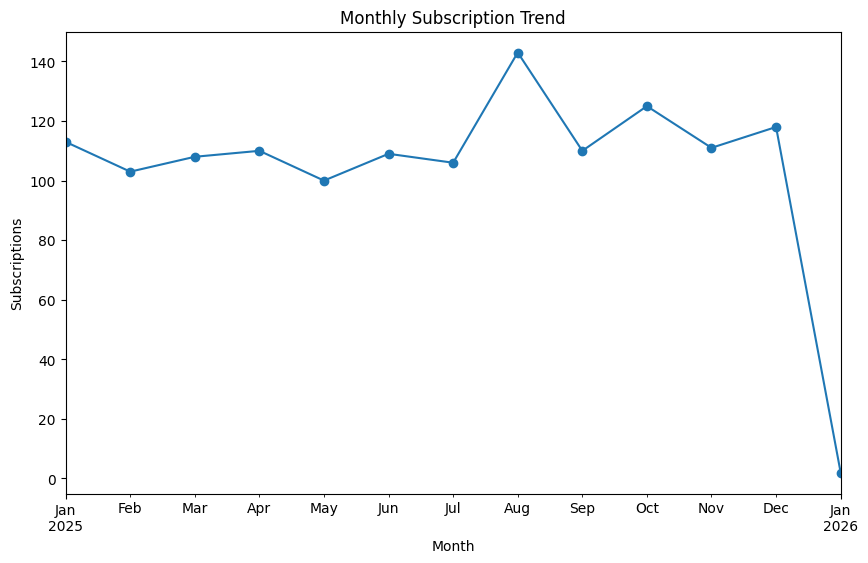

In [36]:
plt.figure(figsize=(10,6))
monthly_subscriptions.plot(kind="line",marker="o")
plt.title("Monthly Subscription Trend")
plt.xlabel("Month")
plt.ylabel("Subscriptions")
plt.show()

In [37]:
churn=(subscriptions[subscriptions['Status']=='Churned'])

In [38]:
monthly_churn=(churn.groupby(churn['End_Date'].dt.to_period("M")).size())

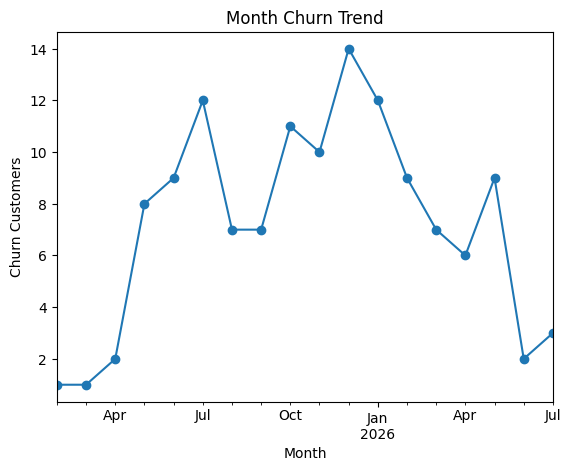

In [39]:
monthly_churn.plot(kind="line",marker='o')
plt.title("Month Churn Trend")
plt.xlabel("Month")
plt.ylabel("Churn Customers")
plt.show()

In [40]:
subscriptions

,Subscription_Id,Customer_Id,Plan_Id,Start_Date,End_Date,Status,Subscription_Days
0,SUB_30000,CUST_2000,p_ent,2025-09-16,NaT,Active,0
1,SUB_30001,CUST_2001,p_pro,2025-10-10,NaT,Active,0
2,SUB_30002,CUST_2002,p_ent,2025-03-21,NaT,Active,0
3,SUB_30004,CUST_2004,p_ent,2025-01-30,NaT,Active,0
4,SUB_30005,CUST_2005,p_pro,2025-04-28,NaT,Active,0
...,...,...,...,...,...,...,...
1353,SUB_31494,CUST_3494,p_pro,2025-01-25,2025-07-05,Churned,161
1354,SUB_31495,CUST_3495,p_pro,2025-09-30,NaT,Active,0
1355,SUB_31496,CUST_3496,p_ent,2025-07-20,NaT,Active,0
1356,SUB_31497,CUST_3497,p_basic,2025-03-26,2025-11-11,Cancelled,230


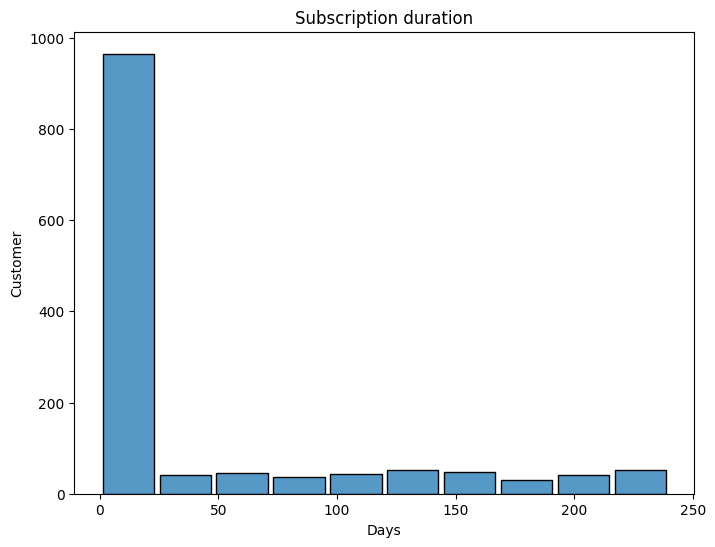

In [41]:
plt.figure(figsize=(8,6))
sns.histplot(data=subscriptions,x='Subscription_Days',shrink=0.9,bins=10)
plt.title("Subscription duration")
plt.xlabel("Days")
plt.ylabel("Customer")
plt.show()

In [42]:
total=len(subscriptions)
total

1358

In [43]:
churned=(subscriptions['Status']=='Churned').sum()
churned

np.int64(130)

In [44]:
churnrate=(churned/total)*100
print(round(churnrate,2))

9.57


# 4. Payments EDA

In [45]:
payments

,Payment_Id,Subscription_Id,Payment_Date,Amount,Payment_Status,Payment_Method
0,PAY_500001,SUB_30000,2025-09-16,-499.0,Refunded,CREDIT_CARD
1,PAY_500002,SUB_30001,2025-10-13,79.0,Paid,STRIPE
2,PAY_500003,SUB_30002,2025-03-24,499.0,Failed,ACH
3,PAY_500004,SUB_30002,2025-04-23,499.0,Failed,PAYPAL
4,PAY_500005,SUB_30002,2025-05-21,499.0,Failed,CREDIT_CARD
...,...,...,...,...,...,...
2808,PAY_503058,SUB_31496,2025-07-21,499.0,Paid,STRIPE
2809,PAY_503059,SUB_31496,2025-08-22,499.0,Failed,CREDIT_CARD
2810,PAY_503060,SUB_31496,2025-09-18,499.0,Paid,CREDIT_CARD
2811,PAY_503061,SUB_31497,2025-03-27,-29.0,Refunded,STRIPE


In [46]:
payments.shape

(2813, 6)

In [47]:
payments.columns

Index(['Payment_Id', 'Subscription_Id', 'Payment_Date', 'Amount',
       'Payment_Status', 'Payment_Method'],
      dtype='object')

In [48]:
payments.dtypes

Payment_Id                 object
Subscription_Id            object
Payment_Date       datetime64[ns]
Amount                    float64
Payment_Status             object
Payment_Method             object
dtype: object

In [49]:
payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2813 entries, 0 to 2812
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Payment_Id       2813 non-null   object        
 1   Subscription_Id  2813 non-null   object        
 2   Payment_Date     2813 non-null   datetime64[ns]
 3   Amount           2813 non-null   float64       
 4   Payment_Status   2813 non-null   object        
 5   Payment_Method   2813 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(4)
memory usage: 132.0+ KB


In [50]:
monthly_revenue=(payments.groupby(payments['Payment_Date'].dt.to_period('M'))['Amount']).sum()
monthly_revenue

Payment_Date
2025-01    11063.0
2025-02     8367.0
2025-03    14813.0
2025-04    25948.0
2025-05    19815.0
2025-06    14385.0
2025-07    17159.0
2025-08    19528.0
2025-09    19279.0
2025-10    23332.0
2025-11    29022.0
2025-12    29873.0
2026-01    14727.0
2026-02     5596.0
2026-03     3184.0
Freq: M, Name: Amount, dtype: float64

In [51]:
payments.describe(include='all')

,Payment_Id,Subscription_Id,Payment_Date,Amount,Payment_Status,Payment_Method
count,2813,2813,2813,2813.000000,2813,2813
unique,2813,1358,NaN,NaN,3,4
top,PAY_503063,SUB_30741,NaN,NaN,Paid,PAYPAL
freq,1,4,NaN,NaN,1420,735
mean,NaN,NaN,2025-08-02 07:20:45.218627584,91.038393,NaN,NaN
min,NaN,NaN,2025-01-03 00:00:00,-499.000000,NaN,NaN
25%,NaN,NaN,2025-05-01 00:00:00,29.000000,NaN,NaN
50%,NaN,NaN,2025-08-08 00:00:00,79.000000,NaN,NaN
75%,NaN,NaN,2025-11-02 00:00:00,79.000000,NaN,NaN
max,NaN,NaN,2026-03-31 00:00:00,499.000000,NaN,NaN


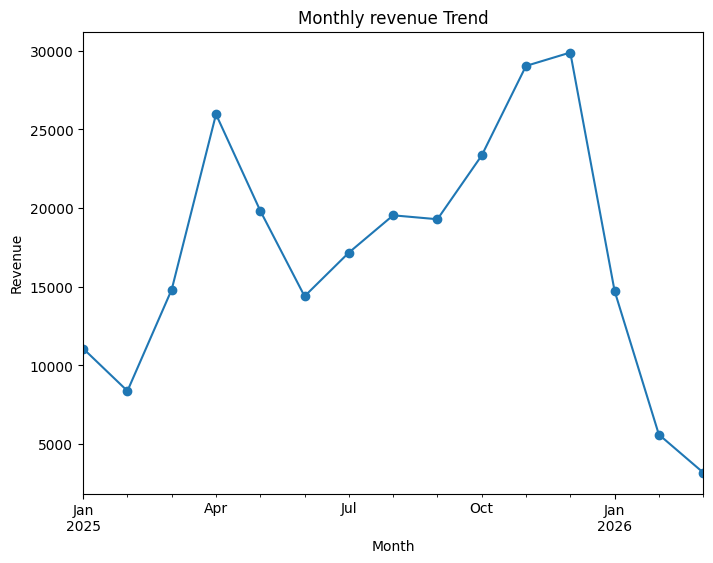

In [52]:
plt.figure(figsize=(8,6))
monthly_revenue.plot(kind='line',marker='o')
plt.title("Monthly revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

In [53]:
status=payments['Payment_Status'].value_counts()
status

Payment_Status
Paid        1420
Failed       706
Refunded     687
Name: count, dtype: int64

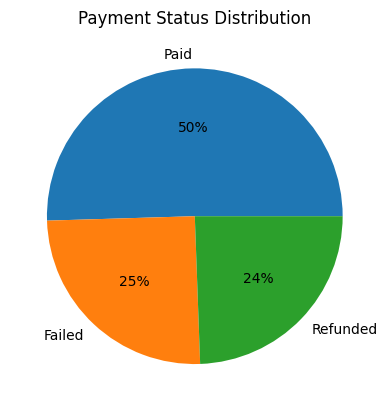

In [54]:
plt.pie(status,labels=status.index,autopct="%1.f%%")
plt.title("Payment Status Distribution")
plt.show()

In [55]:
method=(payments.groupby('Payment_Method')['Amount'].sum().sort_values(ascending=False))
method

Payment_Method
STRIPE         70817.0
PAYPAL         69017.0
CREDIT_CARD    60892.0
ACH            55365.0
Name: Amount, dtype: float64

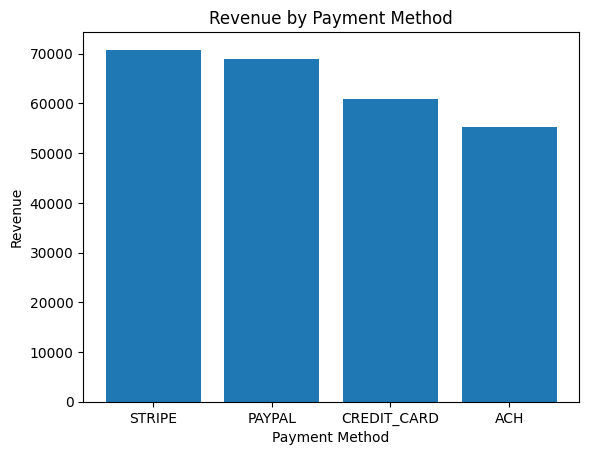

In [56]:
plt.bar(method.index,method.values)
plt.title("Revenue by Payment Method")
plt.xlabel('Payment Method')
plt.ylabel('Revenue')
plt.show()

# 5. Usage EDA

In [57]:
usage

,Usage_Id,Customer_Id,Event_Date,Feature_Name,Login_Count,Session_Minutes
0,USG_700001,CUST_2000,2025-09-08,Dashboard_View,8,114.76
1,USG_700002,CUST_2000,2025-05-11,Export_Csv,3,44.68
2,USG_700003,CUST_2000,2025-01-17,Export_Csv,3,76.59
3,USG_700004,CUST_2000,2025-03-10,Export_Csv,8,58.81
4,USG_700005,CUST_2000,2025-05-25,Export_Csv,3,35.41
...,...,...,...,...,...,...
22697,USG_724752,CUST_2999,2025-01-20,Team_Invite,1,70.09
22698,USG_724753,CUST_2999,2025-01-14,Export_Csv,5,73.85
22699,USG_724754,CUST_2999,2025-05-20,Team_Invite,5,31.07
22700,USG_724755,CUST_2999,2025-10-25,Export_Csv,8,25.97


In [58]:
usage.shape

(22702, 6)

In [59]:
usage.columns

Index(['Usage_Id', 'Customer_Id', 'Event_Date', 'Feature_Name', 'Login_Count',
       'Session_Minutes'],
      dtype='object')

In [60]:
usage.dtypes

Usage_Id                   object
Customer_Id                object
Event_Date         datetime64[ns]
Feature_Name               object
Login_Count                 int64
Session_Minutes           float64
dtype: object

In [61]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22702 entries, 0 to 22701
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Usage_Id         22702 non-null  object        
 1   Customer_Id      22702 non-null  object        
 2   Event_Date       22702 non-null  datetime64[ns]
 3   Feature_Name     22702 non-null  object        
 4   Login_Count      22702 non-null  int64         
 5   Session_Minutes  22702 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(3)
memory usage: 1.0+ MB


In [62]:
usage.describe(include='all')

,Usage_Id,Customer_Id,Event_Date,Feature_Name,Login_Count,Session_Minutes
count,22702,22702,22702,22702,22702.000000,22702.000000
unique,22702,921,NaN,6,NaN,NaN
top,USG_724756,CUST_2896,NaN,Team_Invite,NaN,NaN
freq,1,40,NaN,4419,NaN,NaN
mean,NaN,NaN,2025-06-25 02:07:56.363315712,NaN,4.509030,61.966039
min,NaN,NaN,2025-01-01 00:00:00,NaN,1.000000,5.010000
25%,NaN,NaN,2025-03-29 00:00:00,NaN,3.000000,33.142500
50%,NaN,NaN,2025-06-25 00:00:00,NaN,5.000000,61.660000
75%,NaN,NaN,2025-09-21 00:00:00,NaN,6.000000,90.790000
max,NaN,NaN,2025-12-17 00:00:00,NaN,8.000000,120.000000


In [63]:
usage

,Usage_Id,Customer_Id,Event_Date,Feature_Name,Login_Count,Session_Minutes
0,USG_700001,CUST_2000,2025-09-08,Dashboard_View,8,114.76
1,USG_700002,CUST_2000,2025-05-11,Export_Csv,3,44.68
2,USG_700003,CUST_2000,2025-01-17,Export_Csv,3,76.59
3,USG_700004,CUST_2000,2025-03-10,Export_Csv,8,58.81
4,USG_700005,CUST_2000,2025-05-25,Export_Csv,3,35.41
...,...,...,...,...,...,...
22697,USG_724752,CUST_2999,2025-01-20,Team_Invite,1,70.09
22698,USG_724753,CUST_2999,2025-01-14,Export_Csv,5,73.85
22699,USG_724754,CUST_2999,2025-05-20,Team_Invite,5,31.07
22700,USG_724755,CUST_2999,2025-10-25,Export_Csv,8,25.97


In [64]:
feature=usage['Feature_Name'].value_counts()
feature

Feature_Name
Team_Invite       4419
Dashboard_View    4415
Export_Csv        4350
Billing_Edit      4343
Api_Post          4304
Unknown            871
Name: count, dtype: int64

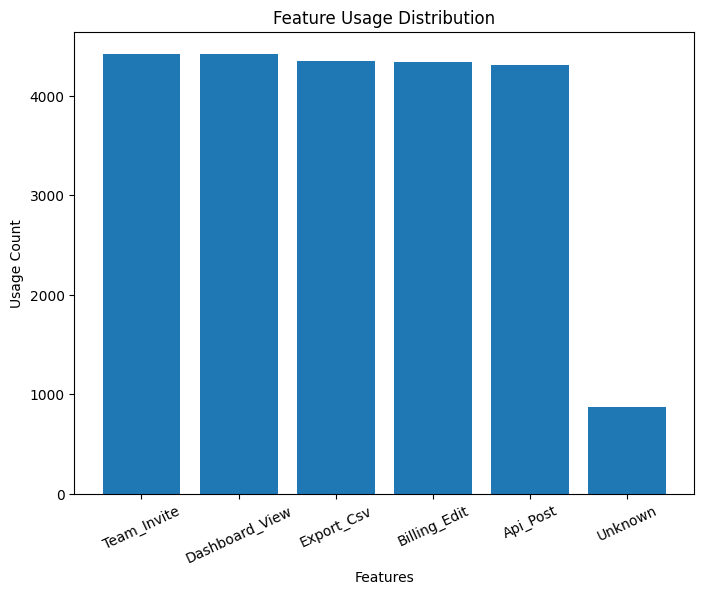

In [65]:
plt.figure(figsize=(8,6))
plt.bar(feature.index,feature.values)
plt.title("Feature Usage Distribution")
plt.xlabel("Features")
plt.ylabel("Usage Count")
plt.xticks(rotation=25)
plt.show()

In [66]:
monthly_usage=(usage.groupby(usage['Event_Date'].dt.to_period("M")).size())
monthly_usage

Event_Date
2025-01    1992
2025-02    1756
2025-03    2073
2025-04    1884
2025-05    2056
2025-06    1910
2025-07    2039
2025-08    2039
2025-09    1961
2025-10    1954
2025-11    1986
2025-12    1052
Freq: M, dtype: int64

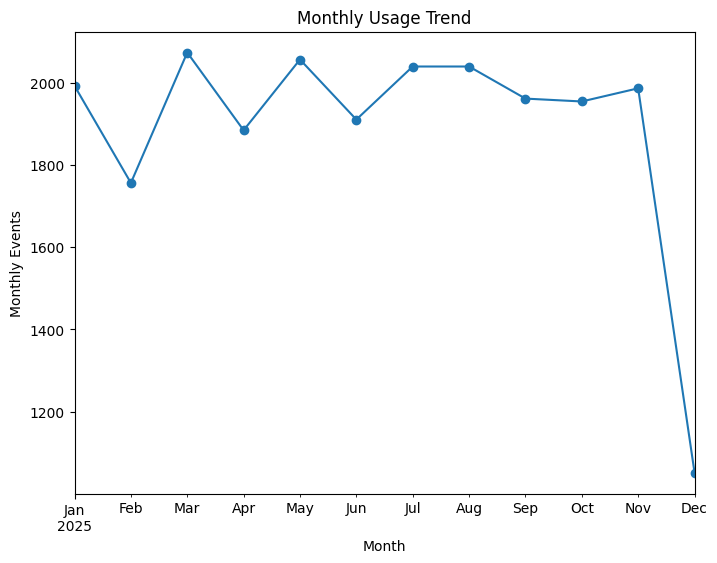

In [67]:
plt.figure(figsize=(8,6))
monthly_usage.plot(kind='line',marker='o')
plt.title("Monthly Usage Trend")
plt.xlabel("Month")
plt.ylabel("Monthly Events")
plt.show()

# 6. Suuport EDA

In [68]:
support

,Ticket_Id,Customer_Id,Ticket_Date,Priority,Category,Resolution_Time,Status
0,TCK_900001,CUST_2006,2025-02-17,High,Login Issue,12,Closed
1,TCK_900002,CUST_2006,2025-07-17,Low,API Down,41,Resolved
2,TCK_900003,CUST_2007,2025-08-23,Low,Login Issue,21,Closed
3,TCK_900004,CUST_2008,2025-11-10,Medium,Login Issue,43,Resolved
4,TCK_900005,CUST_2008,2025-07-22,Medium,Feature Request,1,Resolved
...,...,...,...,...,...,...,...
711,TCK_900780,CUST_3491,2025-07-02,Medium,Feature Request,8,Resolved
712,TCK_900781,CUST_3491,2025-03-02,High,API Down,19,Open
713,TCK_900782,CUST_3496,2025-04-09,Medium,Feature Request,64,Resolved
714,TCK_900783,CUST_3496,2025-08-07,Low,Login Issue,60,Closed


In [69]:
priority=support['Priority'].value_counts().reset_index()
priority.columns=['Priority','Tickets']
priority

,Priority,Tickets
0,High,191
1,Low,183
2,Critical,178
3,Medium,164


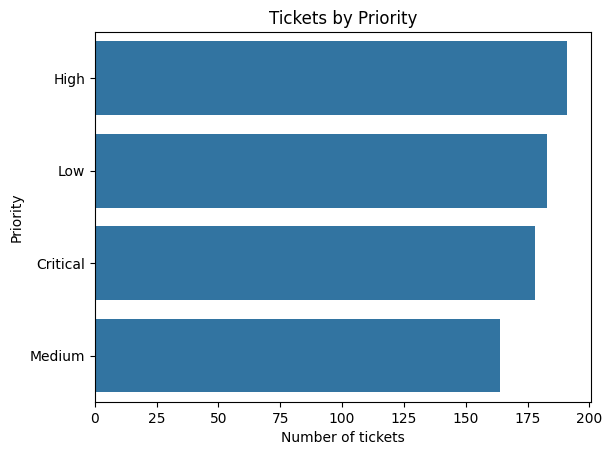

In [70]:
sns.barplot(data=priority,x='Tickets',y='Priority')
plt.title("Tickets by Priority")
plt.xlabel("Number of tickets")
plt.ylabel("Priority")
plt.show()

In [71]:
supportcategory=support["Category"].value_counts().reset_index()
supportcategory.columns=['Category','Tickets']
supportcategory

,Category,Tickets
0,API Down,198
1,Billing Bug,176
2,Login Issue,175
3,Feature Request,167


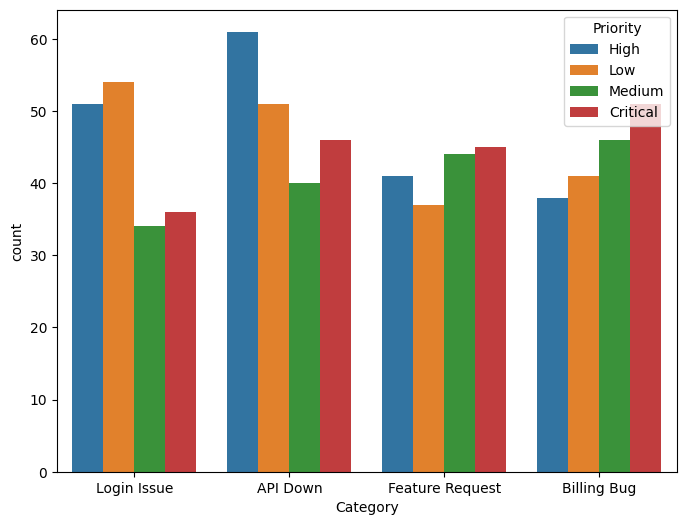

In [72]:
plt.figure(figsize=(8,6))
sns.countplot(data=support,x='Category',hue='Priority')
plt.legend(title="Priority", loc="upper right")
plt.show()

In [73]:
supportstatus=support['Status'].value_counts()
supportstatus

Status
Closed      246
Resolved    242
Open        228
Name: count, dtype: int64

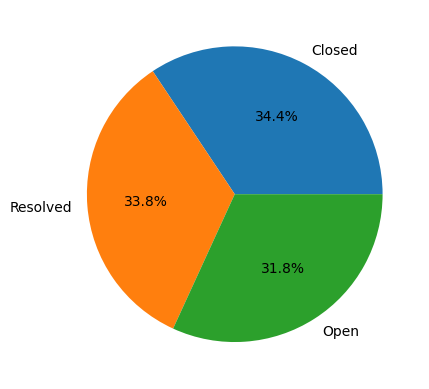

In [74]:
plt.pie(supportstatus,labels=supportstatus.index,autopct="%1.1F%%")
plt.show()

# Conclusion

The exploratory data analysis provided valuable insights into customer behavior, subscription performance, revenue trends, product usage, and support operations.

These findings support strategic business decisions and form the foundation for SQL-based business analysis and the Power BI dashboard developed in the next stages of the project.